<a href="https://colab.research.google.com/github/dellae09/academic-performance-clustering-kmeans-sa/blob/main/04_Master_Capaian_Akademik_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# Tujuan:
# (1) Load hasil final (Pretest, Posttest, Ujian)
# (2) Tampilkan informasi awal tiap dataset (shape, kolom, dtype, missing, preview) + grafik
# (3) Cek kelengkapan (hanya NPM yang ada di ketiganya yang dipakai) -> INNER JOIN
# (4) Bentuk TABEL MASTER: NPM | Nama | Nilai_Pretest | Nilai_Posttest | Nilai_Ujian
# (5) Tampilkan info akhir (jumlah baris, missing, distribusi) lalu SAVE
# ============================================================

***Cell 1 — Mount Drive***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


***[CELL 02] Import Library + Path Output***

In [ ]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PRE_FILE  = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Pretest/pretest_final_wide_1npm_1nilai_2025.csv"
POST_FILE = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Posttest/posttest_final_wide_1npm_1nilai_2025.csv"
UJIAN_FILE= "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Ujian/ujian_final_wide_1npm_1nilai_2025.csv"

OUT_DIR = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/final"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_MASTER = os.path.join(OUT_DIR, "capaian_akademik_master_pre_post_ujian_2025.csv")

***CELL 03 — Utilitas: baca csv + profiling dataset (tabel + diagram)***

In [ ]:
def read_csv_safely(path: str) -> pd.DataFrame:
    # File kamu sudah clean, tapi tetap aman untuk variasi delimiter
    seps = [";", ",", "\t", "|"]
    last_err = None
    for sep in seps:
        try:
            df = pd.read_csv(path, dtype=str, sep=sep, engine="python")
            if df.shape[1] > 1:
                return df
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Gagal membaca CSV: {path}. Error terakhir: {last_err}")

def norm_text(s):
    if pd.isna(s): return ""
    return re.sub(r"\s+", " ", str(s)).strip()

def profile_dataset(df: pd.DataFrame, title: str):
    print("="*110)
    print(f"INFORMASI AWAL DATASET — {title}")
    print("="*110)
    print("Ukuran (baris, kolom):", df.shape)

    print("\nNama kolom:")
    for i, c in enumerate(df.columns, 1):
        print(f"{i:02d}. {c}")

    print("\nDtype per kolom:")
    display(df.dtypes.to_frame("dtype").reset_index().rename(columns={"index":"Kolom"}))

    print("\nPreview 10 baris pertama:")
    display(df.head(10))

    prof = pd.DataFrame({
        "Kolom": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "Missing_Count": [int(df[c].isna().sum()) for c in df.columns],
        "Missing_Rate": [float(df[c].isna().mean()) for c in df.columns],
        "Unique_Count": [int(df[c].nunique(dropna=True)) for c in df.columns],
        "Contoh_Nilai": [
            df[c].dropna().astype(str).head(1).iloc[0] if df[c].dropna().shape[0] else ""
            for c in df.columns
        ],
    }).sort_values(["Missing_Rate", "Unique_Count"], ascending=[False, False])

    print("\nTabel profil (missing, unik, contoh):")
    display(prof)

    # Diagram missing rate top 15
    miss = df.isna().mean().sort_values(ascending=False).head(15)
    plt.figure()
    miss.plot(kind="bar")
    plt.title(f"Missing Rate Top 15 — {title}")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

    return prof

def pick_col(df: pd.DataFrame, candidates: list, label: str) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Kolom {label} tidak ditemukan. Kandidat: {candidates}. Kolom tersedia: {list(df.columns)}")

***CELL 04 — Load dataset final***

In [ ]:
df_pre  = read_csv_safely(PRE_FILE)
df_post = read_csv_safely(POST_FILE)
df_uj   = read_csv_safely(UJIAN_FILE)

print("Loaded:", "PRE", df_pre.shape, "| POST", df_post.shape, "| UJIAN", df_uj.shape)

Loaded: PRE (257, 11) | POST (244, 11) | UJIAN (168, 11)


***CELL 05 — Profil dataset awal (wajib + diagram)***

INFORMASI AWAL DATASET — PRETEST FINAL WIDE
Ukuran (baris, kolom): (257, 11)

Nama kolom:
01. NPM
02. Nama
03. MK_KDP
04. MK_PBO
05. MK_SBD
06. MK_STATPROB
07. MK_ITS
08. MK_KBD
09. MK_DBD
10. Jumlah_MK_Diambil
11. Nilai_Final_0_100

Dtype per kolom:


,Kolom,dtype
0,NPM,object
1,Nama,object
2,MK_KDP,object
3,MK_PBO,object
4,MK_SBD,object
5,MK_STATPROB,object
6,MK_ITS,object
7,MK_KBD,object
8,MK_DBD,object
9,Jumlah_MK_Diambil,object



Preview 10 baris pertama:


,NPM,Nama,MK_KDP,MK_PBO,MK_SBD,MK_STATPROB,MK_ITS,MK_KBD,MK_DBD,Jumlah_MK_Diambil,Nilai_Final_0_100
0,G1F020029,Tegar Sabdo Prasetyo,NaN,NaN,NaN,NaN,16.67,NaN,NaN,1,16.67
1,G1F021019,Fransiscus Juan Sebastian Wibowo,NaN,NaN,28.57,NaN,NaN,NaN,NaN,1,28.57
2,G1F021033,Septiawan,NaN,18.75,NaN,NaN,NaN,NaN,NaN,1,18.75
3,G1F021045,Ananda Naila Evril,NaN,NaN,NaN,78.12,NaN,NaN,NaN,1,78.12
4,G1F022002,Ulfa,NaN,NaN,NaN,NaN,38.89,NaN,NaN,1,38.89
5,G1F022005,Ahmad Fadhila,NaN,NaN,NaN,NaN,NaN,NaN,89.29,1,89.29
6,G1F022007,AHMAD DWICAHYADI,NaN,NaN,NaN,NaN,80.56,NaN,NaN,1,80.56
7,G1F022008,Meisy Dianita,NaN,NaN,NaN,NaN,88.89,NaN,NaN,1,88.89
8,G1F022010,Imam piro,NaN,NaN,NaN,NaN,NaN,NaN,25.0,1,25.0
9,G1F022013,ANNAS ZAM ZAM,NaN,NaN,NaN,NaN,80.56,NaN,NaN,1,80.56



Tabel profil (missing, unik, contoh):


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count,Contoh_Nilai
6,MK_ITS,object,228,0.887160,16,16.67
8,MK_DBD,object,191,0.743191,21,89.29
4,MK_SBD,object,188,0.731518,25,28.57
5,MK_STATPROB,object,186,0.723735,26,78.12
7,MK_KBD,object,186,0.723735,21,16.67
3,MK_PBO,object,179,0.696498,25,18.75
2,MK_KDP,object,168,0.653696,25,10.0
0,NPM,object,0,0.000000,257,G1F020029
1,Nama,object,0,0.000000,257,Tegar Sabdo Prasetyo
10,Nilai_Final_0_100,object,0,0.000000,141,16.67


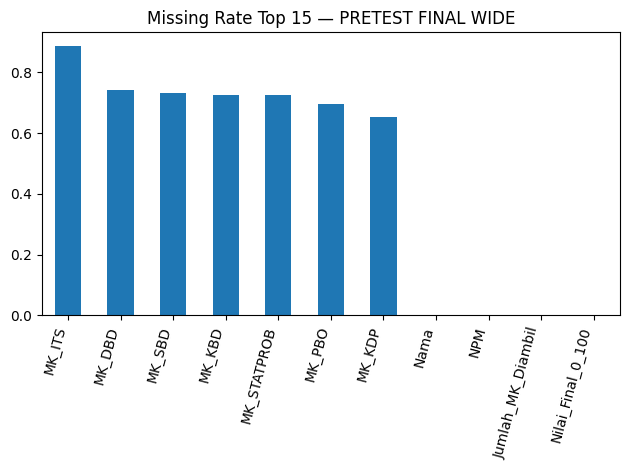

INFORMASI AWAL DATASET — POSTTEST FINAL WIDE
Ukuran (baris, kolom): (244, 11)

Nama kolom:
01. NPM
02. Nama
03. MK_KDP
04. MK_PBO
05. MK_SBD
06. MK_STATPROB
07. MK_ITS
08. MK_KBD
09. MK_DBD
10. Jumlah_MK_Diambil
11. Nilai_Posttest_Final_0_100

Dtype per kolom:


,Kolom,dtype
0,NPM,object
1,Nama,object
2,MK_KDP,object
3,MK_PBO,object
4,MK_SBD,object
5,MK_STATPROB,object
6,MK_ITS,object
7,MK_KBD,object
8,MK_DBD,object
9,Jumlah_MK_Diambil,object



Preview 10 baris pertama:


,NPM,Nama,MK_KDP,MK_PBO,MK_SBD,MK_STATPROB,MK_ITS,MK_KBD,MK_DBD,Jumlah_MK_Diambil,Nilai_Posttest_Final_0_100
0,G1F021045,Ananda Naila Evril,NaN,NaN,NaN,40.62,NaN,NaN,NaN,1,40.62
1,G1F022002,Ulfa,NaN,NaN,NaN,NaN,33.33,NaN,NaN,1,33.33
2,G1F022005,Ahmad Fadhila,NaN,NaN,NaN,NaN,NaN,NaN,64.29,1,64.29
3,G1F022007,AHMAD DWICAHYADI,NaN,NaN,NaN,NaN,41.67,NaN,NaN,1,41.67
4,G1F022008,Meisy Dianita,NaN,NaN,NaN,NaN,88.89,NaN,NaN,1,88.89
5,G1F022013,ANNAS ZAM ZAM,NaN,NaN,NaN,NaN,36.11,NaN,NaN,1,36.11
6,G1F022014,Tanya Dwi Agustin,NaN,NaN,NaN,NaN,72.22,NaN,NaN,1,72.22
7,G1F022016,Epriantravolta Saragih,NaN,87.5,NaN,NaN,NaN,NaN,NaN,1,87.5
8,G1F022019,Della Erlina,NaN,NaN,NaN,NaN,80.56,NaN,NaN,1,80.56
9,G1F022020,Ahmad Ilham Febryadi,NaN,NaN,NaN,NaN,72.22,NaN,NaN,1,72.22



Tabel profil (missing, unik, contoh):


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count,Contoh_Nilai
6,MK_ITS,object,218,0.893443,15,33.33
8,MK_DBD,object,184,0.754098,22,64.29
4,MK_SBD,object,178,0.729508,22,46.43
5,MK_STATPROB,object,176,0.721311,21,40.62
7,MK_KBD,object,175,0.717213,19,30.0
3,MK_PBO,object,172,0.704918,26,87.5
2,MK_KDP,object,158,0.647541,19,72.0
0,NPM,object,0,0.000000,244,G1F021045
1,Nama,object,0,0.000000,244,Ananda Naila Evril
10,Nilai_Posttest_Final_0_100,object,0,0.000000,126,40.62


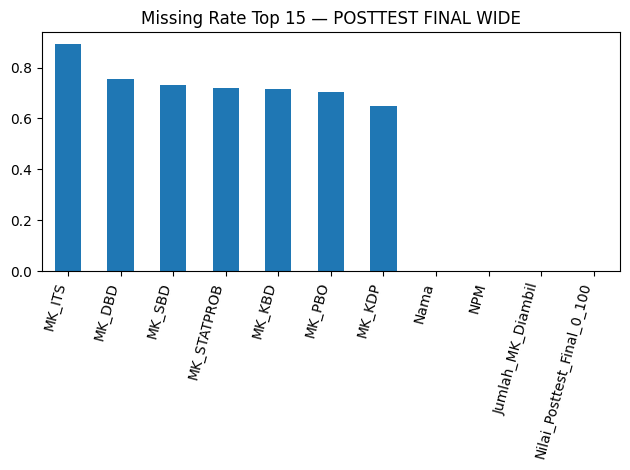

INFORMASI AWAL DATASET — UJIAN FINAL WIDE
Ukuran (baris, kolom): (168, 11)

Nama kolom:
01. NPM
02. Nama
03. MK_KDP
04. MK_PBO
05. MK_SBD
06. MK_STATPROB
07. MK_ITS
08. MK_KBD
09. MK_DBD
10. Jumlah_Record_Ujian
11. Ujian_Final_0_100

Dtype per kolom:


,Kolom,dtype
0,NPM,object
1,Nama,object
2,MK_KDP,object
3,MK_PBO,object
4,MK_SBD,object
5,MK_STATPROB,object
6,MK_ITS,object
7,MK_KBD,object
8,MK_DBD,object
9,Jumlah_Record_Ujian,object



Preview 10 baris pertama:


,NPM,Nama,MK_KDP,MK_PBO,MK_SBD,MK_STATPROB,MK_ITS,MK_KBD,MK_DBD,Jumlah_Record_Ujian,Ujian_Final_0_100
0,G1F021019,Fransiscus Juan Sebastian Wibowo,NaN,66.67,80.77,NaN,NaN,NaN,NaN,2,73.72
1,G1F021033,Septiawan,NaN,19.05,NaN,NaN,NaN,NaN,NaN,1,19.05
2,G1F021038,Fachrul Rozi Ramadhan,NaN,80.95,NaN,NaN,NaN,NaN,NaN,1,80.95
3,G1F021045,Ananda Naila Evril,NaN,NaN,NaN,57.14,NaN,NaN,NaN,1,57.14
4,G1F022002,Ulfa,NaN,NaN,NaN,NaN,48.0,NaN,NaN,1,48.0
5,G1F022005,Ahmad Fadhila,NaN,NaN,NaN,NaN,NaN,NaN,62.07,1,62.07
6,G1F022007,AHMAD DWICAHYADI,NaN,NaN,NaN,NaN,28.0,NaN,NaN,1,28.0
7,G1F022008,Meisy Dianita,NaN,NaN,NaN,NaN,84.0,NaN,NaN,1,84.0
8,G1F022010,Imam piro,NaN,NaN,NaN,NaN,NaN,NaN,34.48,1,34.48
9,G1F022013,ANNAS ZAM ZAM,NaN,NaN,NaN,NaN,64.0,NaN,NaN,1,64.0



Tabel profil (missing, unik, contoh):


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count,Contoh_Nilai
2,MK_KDP,object,168,1.000000,0,
6,MK_ITS,object,139,0.827381,14,48.0
8,MK_DBD,object,105,0.625000,18,62.07
4,MK_SBD,object,99,0.589286,17,80.77
7,MK_KBD,object,98,0.583333,18,23.33
5,MK_STATPROB,object,97,0.577381,15,57.14
3,MK_PBO,object,88,0.523810,19,66.67
0,NPM,object,0,0.000000,168,G1F021019
1,Nama,object,0,0.000000,168,Fransiscus Juan Sebastian Wibowo
10,Ujian_Final_0_100,object,0,0.000000,115,73.72


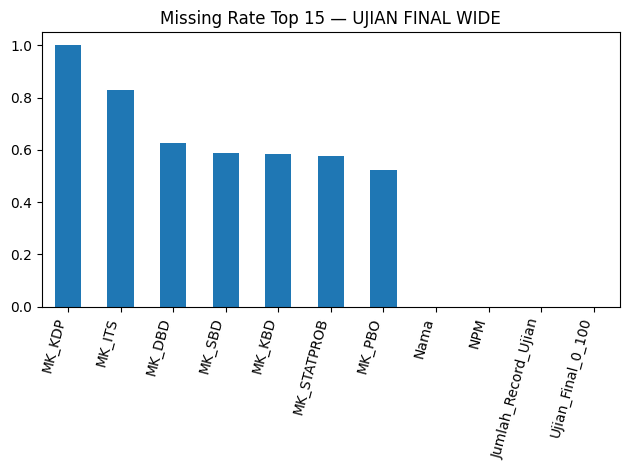

In [ ]:
prof_pre  = profile_dataset(df_pre,  "PRETEST FINAL WIDE")
prof_post = profile_dataset(df_post, "POSTTEST FINAL WIDE")
prof_uj   = profile_dataset(df_uj,   "UJIAN FINAL WIDE")

***CELL 06 — Standarisasi minimal untuk merge (NPM, Nama, skor)***

In [ ]:
# ============================================================
# Kandidat kolom skor (robust terhadap perbedaan penamaan)
pre_score_col  = pick_col(df_pre,  ["Nilai_Final_0_100", "Pretest_Final_0_100", "Pretest_Final"], "skor PRETEST")
post_score_col = pick_col(df_post, ["Nilai_Posttest_Final_0_100", "Posttest_Final_0_100", "Nilai_Final_0_100"], "skor POSTTEST")
uj_score_col   = pick_col(df_uj,   ["Ujian_Final_0_100", "Nilai_Ujian_Final_0_100", "Nilai_Final_0_100"], "skor UJIAN")

# Normalisasi NPM & Nama
def prep_min(df: pd.DataFrame, score_col: str, score_name: str) -> pd.DataFrame:
    out = df.copy()

    # pastikan ada kolom NPM & Nama
    if "NPM" not in out.columns:
        raise ValueError("Kolom NPM tidak ada di dataset.")
    if "Nama" not in out.columns:
        raise ValueError("Kolom Nama tidak ada di dataset.")

    out["NPM"]  = out["NPM"].apply(norm_text).str.upper()
    out["Nama"] = out["Nama"].apply(norm_text)

    # skor numeric
    out[score_name] = pd.to_numeric(out[score_col], errors="coerce")

    return out[["NPM", "Nama", score_name]].copy()

pre_min  = prep_min(df_pre,  pre_score_col,  "Nilai_Pretest")
post_min = prep_min(df_post, post_score_col, "Nilai_Posttest")
uj_min   = prep_min(df_uj,   uj_score_col,   "Nilai_Ujian")

print("Kolom skor terpakai:")
print("PRE :", pre_score_col, "-> Nilai_Pretest")
print("POST:", post_score_col, "-> Nilai_Posttest")
print("UJ  :", uj_score_col, "-> Nilai_Ujian")

display(pre_min.head(5))
display(post_min.head(5))
display(uj_min.head(5))


Kolom skor terpakai:
PRE : Nilai_Final_0_100 -> Nilai_Pretest
POST: Nilai_Posttest_Final_0_100 -> Nilai_Posttest
UJ  : Ujian_Final_0_100 -> Nilai_Ujian


,NPM,Nama,Nilai_Pretest
0,G1F020029,Tegar Sabdo Prasetyo,16.67
1,G1F021019,Fransiscus Juan Sebastian Wibowo,28.57
2,G1F021033,Septiawan,18.75
3,G1F021045,Ananda Naila Evril,78.12
4,G1F022002,Ulfa,38.89


,NPM,Nama,Nilai_Posttest
0,G1F021045,Ananda Naila Evril,40.62
1,G1F022002,Ulfa,33.33
2,G1F022005,Ahmad Fadhila,64.29
3,G1F022007,AHMAD DWICAHYADI,41.67
4,G1F022008,Meisy Dianita,88.89


,NPM,Nama,Nilai_Ujian
0,G1F021019,Fransiscus Juan Sebastian Wibowo,73.72
1,G1F021033,Septiawan,19.05
2,G1F021038,Fachrul Rozi Ramadhan,80.95
3,G1F021045,Ananda Naila Evril,57.14
4,G1F022002,Ulfa,48.00


***ELL 07 — Audit coverage (berapa NPM ada di masing-masing & irisan)***

AUDIT KELENGKAPAN (NPM)
NPM unik PRE : 257
NPM unik POST: 244
NPM unik UJ  : 168
NPM unik irisan (PRE ∩ POST ∩ UJ): 156
Akan dipakai hanya irisan (lengkap di ketiganya).


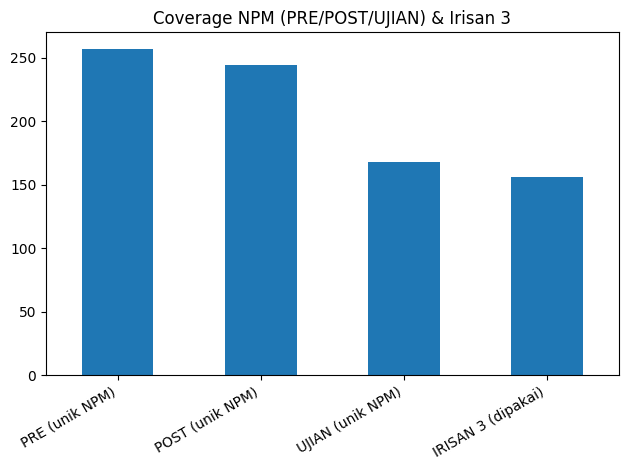

In [ ]:
s_pre  = set(pre_min["NPM"].dropna())
s_post = set(post_min["NPM"].dropna())
s_uj   = set(uj_min["NPM"].dropna())

intersect_all = s_pre & s_post & s_uj

print("="*110)
print("AUDIT KELENGKAPAN (NPM)")
print("="*110)
print("NPM unik PRE :", len(s_pre))
print("NPM unik POST:", len(s_post))
print("NPM unik UJ  :", len(s_uj))
print("NPM unik irisan (PRE ∩ POST ∩ UJ):", len(intersect_all))
print("Akan dipakai hanya irisan (lengkap di ketiganya).")

# Visual bar sederhana
counts = pd.Series({
    "PRE (unik NPM)": len(s_pre),
    "POST (unik NPM)": len(s_post),
    "UJIAN (unik NPM)": len(s_uj),
    "IRISAN 3 (dipakai)": len(intersect_all),
})
plt.figure()
counts.plot(kind="bar")
plt.title("Coverage NPM (PRE/POST/UJIAN) & Irisan 3")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

***CELL 08 — Merge master (INNER JOIN) -> hanya mahasiswa lengkap di ketiganya***

In [ ]:
# ============================================================
# merge berdasarkan NPM saja (paling stabil). Nama diambil dari PRE sebagai referensi utama.
master = (
    pre_min.merge(post_min[["NPM", "Nilai_Posttest", "Nama"]], on="NPM", how="inner", suffixes=("_pre", "_post"))
          .merge(uj_min[["NPM", "Nilai_Ujian", "Nama"]], on="NPM", how="inner", suffixes=("", "_uj"))
)

# Nama: prioritaskan Nama dari PRE, lalu fallback jika kosong
master["Nama_Final"] = master["Nama_pre"].where(master["Nama_pre"].astype(str).str.strip().ne(""), master["Nama_post"])
master["Nama_Final"] = master["Nama_Final"].where(master["Nama_Final"].astype(str).str.strip().ne(""), master["Nama"])
master["Nama_Final"] = master["Nama_Final"].apply(norm_text)

# Rapikan kolom
master = master[["NPM", "Nama_Final", "Nilai_Pretest", "Nilai_Posttest", "Nilai_Ujian"]].rename(columns={"Nama_Final":"Nama"}).copy()

# Bulatkan 2 desimal
for c in ["Nilai_Pretest", "Nilai_Posttest", "Nilai_Ujian"]:
    master[c] = pd.to_numeric(master[c], errors="coerce").round(2)

print("="*110)
print("HASIL MERGE MASTER (SEBELUM FILTER NILAI NaN)")
print("="*110)
print("Ukuran master:", master.shape)
display(master.head(10))

HASIL MERGE MASTER (SEBELUM FILTER NILAI NaN)
Ukuran master: (156, 5)


,NPM,Nama,Nilai_Pretest,Nilai_Posttest,Nilai_Ujian
0,G1F021045,Ananda Naila Evril,78.12,40.62,57.14
1,G1F022002,Ulfa,38.89,33.33,48.00
2,G1F022005,Ahmad Fadhila,89.29,64.29,62.07
3,G1F022007,AHMAD DWICAHYADI,80.56,41.67,28.00
4,G1F022008,Meisy Dianita,88.89,88.89,84.00
5,G1F022013,ANNAS ZAM ZAM,80.56,36.11,64.00
6,G1F022014,Tanya Dwi Agustin,50.00,72.22,64.00
7,G1F022016,Epriantravolta Saragih,81.25,87.50,47.62
8,G1F022019,Della Erlina,77.78,80.56,80.00
9,G1F022020,Ahmad Ilham Febryadi,69.44,72.22,56.00


***CELL 09 — Validasi akhir: wajib lengkap nilai 3 kolom***

FILTER KELENGKAPAN NILAI (PRE+POST+UJIAN wajib ada)
Sebelum: 156 | Sesudah: 156 | Tercoret: 0
Duplikasi NPM (harus 0): 0


,NPM,Nama,Nilai_Pretest,Nilai_Posttest,Nilai_Ujian
0,G1F021045,Ananda Naila Evril,78.12,40.62,57.14
1,G1F022002,Ulfa,38.89,33.33,48.00
2,G1F022005,Ahmad Fadhila,89.29,64.29,62.07
3,G1F022007,AHMAD DWICAHYADI,80.56,41.67,28.00
4,G1F022008,Meisy Dianita,88.89,88.89,84.00
5,G1F022013,ANNAS ZAM ZAM,80.56,36.11,64.00
6,G1F022014,Tanya Dwi Agustin,50.00,72.22,64.00
7,G1F022016,Epriantravolta Saragih,81.25,87.50,47.62
8,G1F022019,Della Erlina,77.78,80.56,80.00
9,G1F022020,Ahmad Ilham Febryadi,69.44,72.22,56.00


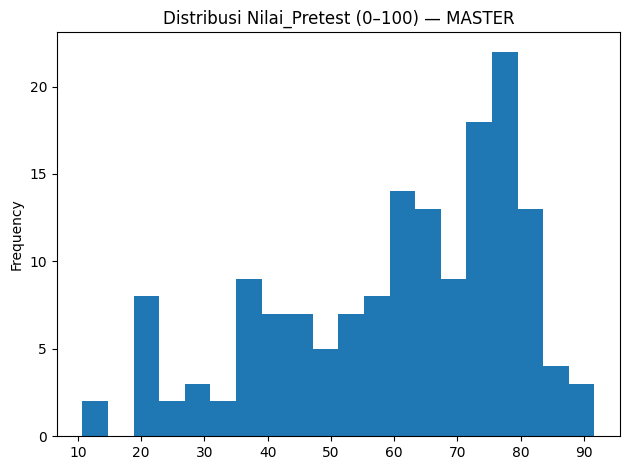

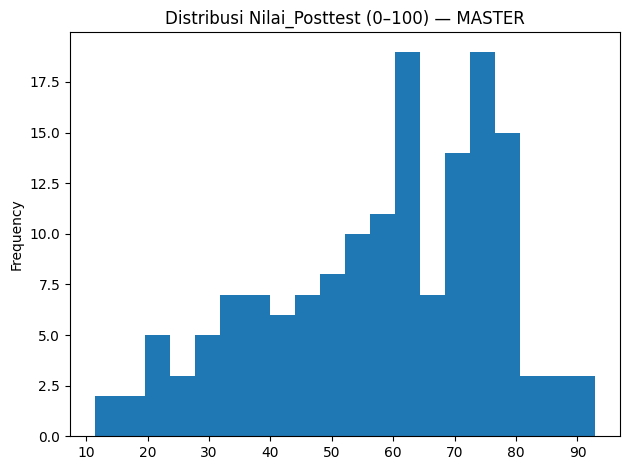

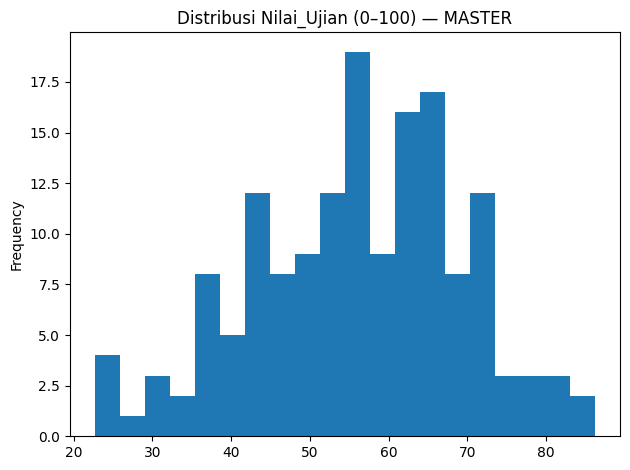

In [ ]:
before = master.shape[0]
master_complete = master.dropna(subset=["Nilai_Pretest", "Nilai_Posttest", "Nilai_Ujian"]).copy()
after = master_complete.shape[0]

print("="*110)
print("FILTER KELENGKAPAN NILAI (PRE+POST+UJIAN wajib ada)")
print("="*110)
print("Sebelum:", before, "| Sesudah:", after, "| Tercoret:", before - after)

# Cek duplikat NPM
dup_npm = int(master_complete["NPM"].duplicated().sum())
print("Duplikasi NPM (harus 0):", dup_npm)

display(master_complete.head(10))

# Grafik distribusi nilai final (opsional tapi informatif)
plt.figure()
master_complete["Nilai_Pretest"].plot(kind="hist", bins=20)
plt.title("Distribusi Nilai_Pretest (0–100) — MASTER")
plt.tight_layout()
plt.show()

plt.figure()
master_complete["Nilai_Posttest"].plot(kind="hist", bins=20)
plt.title("Distribusi Nilai_Posttest (0–100) — MASTER")
plt.tight_layout()
plt.show()

plt.figure()
master_complete["Nilai_Ujian"].plot(kind="hist", bins=20)
plt.title("Distribusi Nilai_Ujian (0–100) — MASTER")
plt.tight_layout()
plt.show()

***CELL 10 — Info akhir nilai master + Save***

In [ ]:
print("="*110)
print("INFORMASI DATASET MASTER (FINAL) — sebelum SAVE")
print("="*110)
print("Ukuran (baris, kolom):", master_complete.shape)
print("Kolom:", list(master_complete.columns))
print("Missing per kolom:")
display(master_complete.isna().sum().to_frame("Missing_Count"))

print("\nPreview 10 baris:")
display(master_complete.head(10))

master_complete.to_csv(OUT_MASTER, index=False)
print("MASTER tersimpan:", OUT_MASTER)
print("Lokasi output folder:", OUT_DIR)

INFORMASI DATASET MASTER (FINAL) — sebelum SAVE
Ukuran (baris, kolom): (156, 5)
Kolom: ['NPM', 'Nama', 'Nilai_Pretest', 'Nilai_Posttest', 'Nilai_Ujian']
Missing per kolom:


,Missing_Count
NPM,0
Nama,0
Nilai_Pretest,0
Nilai_Posttest,0
Nilai_Ujian,0



Preview 10 baris:


,NPM,Nama,Nilai_Pretest,Nilai_Posttest,Nilai_Ujian
0,G1F021045,Ananda Naila Evril,78.12,40.62,57.14
1,G1F022002,Ulfa,38.89,33.33,48.00
2,G1F022005,Ahmad Fadhila,89.29,64.29,62.07
3,G1F022007,AHMAD DWICAHYADI,80.56,41.67,28.00
4,G1F022008,Meisy Dianita,88.89,88.89,84.00
5,G1F022013,ANNAS ZAM ZAM,80.56,36.11,64.00
6,G1F022014,Tanya Dwi Agustin,50.00,72.22,64.00
7,G1F022016,Epriantravolta Saragih,81.25,87.50,47.62
8,G1F022019,Della Erlina,77.78,80.56,80.00
9,G1F022020,Ahmad Ilham Febryadi,69.44,72.22,56.00


MASTER tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/final/capaian_akademik_master_pre_post_ujian_2025.csv
Lokasi output folder: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/final
